In [ ]:
# http://api.catusita.com:8083/api/sales/forDate?Date1=20250101&Date2=20250115
# http://api.catusita.com:8083/api/stock/forDate?DateStock=20250210
# http://api.catusita.com:8083/api/article/data

In [75]:
import pandas as pd
import numpy as np
import requests
import yfinance as yf
import math
from datetime import datetime, timedelta
from typing import Tuple, Optional


def fetch_data_from_api(url: str, params: dict = None) -> pd.DataFrame:
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json().get("data", [])
        return pd.DataFrame(data)
    except requests.exceptions.RequestException as e:
        print(f"Error al conectar con la API {url}: {e}")
        return pd.DataFrame()

df_predictions = pd.read_csv("data/cleaned/predictions.csv")
df_rfm = pd.read_csv("data/process/df_rfm.csv")
df_products = pd.read_csv("data/process/catusita_consolidated.csv")
try:
    df_backorder = pd.read_excel("data/raw/catusita/backorder12_12.xlsx")
except FileNotFoundError:
    df_backorder = pd.DataFrame()
prev_day = (datetime.now() - timedelta(days=1)).strftime("%Y%m%d")
df_inventory = fetch_data_from_api("http://api.catusita.com:8083/api/stock/forDate", {"DateStock": prev_day})
df_tc = fetch_data_from_api("http://api.catusita.com:8083/api/article/data")


### to_datime
df_products['fecha'] = pd.to_datetime(df_products['fecha'])
df_predictions['date'] = pd.to_datetime(df_predictions['date'])

df_tc = df_tc[df_tc["lastDateBuy"] != "0001-01-01T00:00:00"]
df_tc["lastDateBuy"] = pd.to_datetime(df_tc["lastDateBuy"], format="%Y-%m-%dT%H:%M:%S", errors="coerce")
df_tc = df_tc[(df_tc["lastDateBuy"] >= "1900-01-01") & (df_tc["lastDateBuy"] <= "2030-12-31")]

### processing data for raw tables
## df_tc
df_tc['codeArticle'] = df_tc['codeArticle'].astype(str)
df_tc['codeArticle'] = df_tc['codeArticle'].str.lower()
df_tc.to_csv('articulos.csv')
df_tc = df_tc.rename(columns={
    'codeArticle':'codigo',
    'lastCurrencyBuy':'moneda',
    'lastPriceBuy':'monto',
    'lastDateBuy':'ultima_fecha',
    'lastQuantityBuy':'ultima_compra'
    })
df_tc = df_tc.dropna(subset=['ultima_fecha'])
df_tc = df_tc[df_tc['ultima_fecha'].notna()]

## df_product
df_products['fecha_mensual'] = df_products['fecha'].dt.to_period('M').dt.to_timestamp()       
# crear variable precio
df_products['precio'] = df_products['venta_pen'] / df_products['cantidad']
# crear variable margen
df_products['margen'] = df_products['venta_pen'] / df_products['costo'] - 1
df_margin_result = df_products.groupby('articulo').agg(
    total_venta_pen=('venta_pen', 'sum'),
    mean_margen=('margen', 'mean')
).reset_index().sort_values(by='total_venta_pen', ascending=False)
# agregar por fecha_mensual, articulo, fuente_suministro 
df_products = df_products.groupby(['fecha_mensual', 'articulo', 'fuente_suministro']).agg({
    # 'descripcion': 'first',
    'cantidad': 'sum',
    'transacciones': 'sum',
    'venta_pen': 'sum', 
    'costo': 'mean',
    'precio': 'mean',
    'lt': 'first'
}).reset_index().rename(columns={'venta_pen': 'total_venta_pen','margen': 'mean_margen'})

## df_predictions
df_predictions = df_predictions.rename(columns={'sku': 'articulo'})

## df_inventory
df_inventory = df_inventory.rename(columns={
    "codeArticle": "codigo",
    "umArticle": "um",
    "stock": "stock"
})
df_inventory.loc[:, 'codigo'] = df_inventory['codigo'].str.lower()
df_inventory = df_inventory.groupby(['codigo','um']).agg(
    {
        'stock':'sum'
    }
).reset_index()



# Get currency data 
start = df_tc['ultima_fecha'].min().date()
end = df_tc['ultima_fecha'].max().date()
currency_pairs = ['PENUSD=X', 'EURUSD=X', 'JPYUSD=X', 'GBPUSD=X']
data = yf.download(currency_pairs, start=start, end=end)
df_closing_prices = data['Close']
df_closing_prices.columns = [col.split('.')[0] for col in df_closing_prices.columns]

# process currency data
df_long_format = df_closing_prices.reset_index().melt(id_vars='Date', var_name='Currency Pair', value_name='Closing Price')
df_long_format['Currency Pair'] = df_long_format['Currency Pair'].str.replace('=X', '', regex=False)
df_long_format = df_long_format.dropna(subset=['Closing Price'])

full_date_range = pd.date_range(start=df_long_format['Date'].min(), end=df_long_format['Date'].max(), freq='D')
currency_pairs = df_long_format['Currency Pair'].unique()
complete_index = pd.MultiIndex.from_product([full_date_range, currency_pairs], names=['Date', 'Currency Pair'])
df_temp = pd.DataFrame(index=complete_index).reset_index()

df_long_format = df_temp.merge(df_long_format, on=['Date', 'Currency Pair'], how='left')
df_long_format['Closing Price'] = df_long_format.groupby('Currency Pair')['Closing Price'].ffill()
df_long_format = df_long_format.rename(columns={'Closing Price': 'tc'})

# merge exchange rates
df_tc_merged = pd.merge(df_tc, df_long_format, left_on='ultima_fecha', right_on='Date', how='left')
df_tc_merged['monto'] = pd.to_numeric(df_tc_merged['monto'], errors='coerce')
df_tc_merged['tc'] = pd.to_numeric(df_tc_merged['tc'], errors='coerce')

def convert_to_usd(row):
    if pd.isna(row['Currency Pair']) or row['moneda'] == 'USD':
        return row['monto']
    currency_pair_map = {'SOL': 'PENUSD', 'EUR': 'EURUSD', 'JPY': 'JPYUSD', 'GBP': 'GBPUSD'}
    if row['moneda'] in currency_pair_map and row['Currency Pair'] == currency_pair_map[row['moneda']]:
        return row['monto'] / row['tc'] if row['moneda'] == 'SOL' else row['monto'] * row['tc']
    return 0

df_tc_merged['monto_usd'] = df_tc_merged.apply(convert_to_usd, axis=1)
df_tc_merged = df_tc_merged[df_tc_merged['monto_usd'] != 0]
df_tc_final = df_tc_merged[['codigo', 'ultima_fecha', 'monto_usd', 'ultima_compra']]
df_tc_final = df_tc_final[df_tc_final['monto_usd'].notna()]

# cleaning df_inventory with df_products
# max_date = df_inventory['date'].max()
# df_inventory = df_inventory[
#     (df_inventory['date'] != 'Periodo') & 
#     (df_inventory['date'].notna())&
#     (df_inventory['date']==max_date)
# ]
df_inventory_final=pd.concat(
    [
        pd.DataFrame(df_inventory['codigo'].unique(), columns=['codigo']),
        pd.DataFrame(df_products['articulo'].unique(), columns=['codigo'])
    ], 
    ignore_index=True
).drop_duplicates()
df_inventory = df_inventory_final.merge(
#    df_inventory[['date','codigo','stock']].drop_duplicates(),
    df_inventory[['codigo','stock']].drop_duplicates(),
    how='left',
    on='codigo'
)
df_inventory['stock']=df_inventory['stock'].fillna(0)
# df_inventory['date'] = df_inventory['date'].fillna(max_date)
# merging df_predictions, df_products and df_invetory
df_merged = df_predictions.copy()
df_merged = df_merged.merge(
    df_products[['articulo','fuente_suministro']].drop_duplicates(), 
    how='left', 
    on = 'articulo'
)
df_merged = df_merged.merge(
    df_inventory[['codigo','stock']], 
    how='left', 
    left_on=['articulo'],
    right_on=['codigo']
)

# merging df_tc_final, df_backorder, rfm and df_margin_result
df_merged = df_merged.merge(
    df_margin_result[['articulo', 'mean_margen']], 
    how='left', 
    on='articulo'
)
df_merged = df_merged.merge(
    df_tc_final, 
    how='left', 
    left_on='articulo', 
    right_on='codigo'
)
if not df_backorder.empty:
    df_merged = df_merged.merge(
        df_backorder, 
        how='left', 
        on='articulo'
    )
else:
    df_merged['backorder'] = np.nan
df_merged = df_merged.merge(
    df_rfm, 
    left_on='articulo',
    right_on='sku',
    how='left'
)
df_merged['rfm'] = df_merged['rfm'].fillna(0).astype(int)
df_merged = df_merged.drop_duplicates()

# adding demanda_mensual and meses_proteccion    
df_merged['demanda_mensual'] = df_merged['caa'] / df_merged['lt']
df_merged['meses_proteccion'] = df_merged['corr_sd'] / df_merged['demanda_mensual']

# adding compra_sugerida
df_merged['sobrante'] = np.maximum(df_merged['stock'].fillna(0) + df_merged['backorder'].fillna(0) - df_merged['caa_lt'], 0)
df_merged['compra_sugerida'] = np.maximum(df_merged['caa'].fillna(0) - df_merged['sobrante'], 0)
df_merged['compra_sugerida'] = np.ceil(df_merged['compra_sugerida']).astype('Int64')
df_merged['compra_sugerida'] = df_merged['compra_sugerida'].astype("Float64")
df_merged['meses_proteccion'] = df_merged['meses_proteccion'].astype("Float64")
# mask = df_merged['demanda_mensual'] != 0
# df_merged.loc[mask, 'meses_proteccion'] = (
#     df_merged.loc[mask, 'meses_proteccion'] * 
#     (df_merged.loc[mask, 'compra_sugerida'].fillna(0) / df_merged.loc[mask, 'demanda_mensual'])
# ).astype("Float64")

# adding costo_compra and compras_recomendadas
# df_merged = df_merged.rename(columns={'caa': 'compras_recomendadas'})
df_merged = df_merged.rename(columns={'compra_sugerida': 'compras_recomendadas'})
df_merged.loc[df_merged['demanda_mensual'] < 0, 'demanda_mensual'] = 0
df_merged.loc[df_merged['compras_recomendadas'] < 0, 'compras_recomendadas'] = 0
df_merged['compras_recomendadas'] = df_merged['compras_recomendadas'].apply(
    lambda x: math.ceil(x / 50) * 50 if pd.notna(x) else pd.NA
)
df_merged['costo_compra'] = df_merged['monto_usd'] * df_merged['compras_recomendadas']

# Calcular riesgo
df_merged['holgura'] = (df_merged['stock'] / df_merged['demanda_mensual']).fillna(0)
df_merged['consumiendo_proteccion'] = (df_merged['holgura'] < df_merged['meses_proteccion']).astype('Int64')
df_merged['quebro'] = (df_merged['holgura'] <= 0).astype('Int64')
df_merged['va_a_quebrar'] = ((df_merged['stock'] + df_merged['backorder']) < df_merged['demanda_mensual']).astype('Int64')
df_merged['verde'] = (
    (df_merged['quebro'] == 0) & 
    (df_merged['consumiendo_proteccion'] == 0) & 
    (df_merged['va_a_quebrar'] == 0)
).astype('Int64')
df_merged['amarillo'] = (
    (df_merged['consumiendo_proteccion'] == 1) & 
    (df_merged['quebro'] == 0)
).astype('Int64')
df_merged['rojo'] = (
    (df_merged['quebro'] == 1) |
    (df_merged['va_a_quebrar'] == 1) 
).astype('Int64')
df_merged['riesgo'] = df_merged.apply(
    lambda row: 'rojo' if pd.notna(row.get('rojo')) and row['rojo'] == 1 else 
                'amarillo' if pd.notna(row.get('amarillo')) and row['amarillo'] == 1 else 
                ('verde' if pd.notna(row.get('rojo')) or pd.notna(row.get('amarillo')) else np.nan),
    axis=1
)

# modificar period2 (caa_lt)
df_merged['caa_lt'] += df_merged['corr_sd'] * df_merged['rfm'].map({3: 0.4, 2: 0.3, 1: 0.2, 0: 0.1}).fillna(0)

# filtrar solo las importantes para la tabla por fuente de suministro
df_merged['demanda_mensual_usd'] = df_merged['demanda_mensual'] * df_merged['monto_usd']
df_temp = df_merged.copy()
df_temp = df_temp[(df_temp['rfm'] == 3) & (df_temp['riesgo'] == 'rojo')]
df_temp = df_temp.groupby('fuente_suministro').agg(
    recomendacion=('costo_compra', 'sum'),
    demanda_mensual_usd=('demanda_mensual_usd', 'sum')
).reset_index()
df_temp_2 = df_merged.groupby('fuente_suministro').agg(
    lead_time=('lt', 'first'),
    riesgo=('riesgo', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()
df_dashboard_by_fuente = df_temp_2.merge(df_temp, how='left', on='fuente_suministro')
df_dashboard_by_fuente['recomendacion'] = pd.to_numeric(df_dashboard_by_fuente['recomendacion'], errors='coerce').fillna(0).astype(int)
df_dashboard_by_fuente['demanda_mensual_usd'] = pd.to_numeric(df_dashboard_by_fuente['demanda_mensual_usd'], errors='coerce').fillna(0).astype(int)

# dar formato
df_dashboard_by_fuente['riesgo_color'] = df_dashboard_by_fuente['riesgo'].map({
    'verde': '🟢',
    'amarillo': '🟡',
    #'naranja': '🟠',
    'rojo': '🔴'
})
df_download = df_merged[[
    'date','articulo','fuente_suministro','stock','compras_recomendadas','demanda_mensual',
    'meses_proteccion','riesgo','lt','mean_margen','ultima_fecha','monto_usd',
    'ultima_compra','costo_compra','rfm','backorder','holgura','quebro','va_a_quebrar','consumiendo_proteccion'
]]
df_dashboard = df_merged[[
    'date','articulo','fuente_suministro','stock','backorder','rfm','riesgo',
    'demanda_mensual','monto_usd','ultima_compra','compras_recomendadas','costo_compra'
]]
df_dashboard_by_fuente = df_dashboard_by_fuente[[
    'fuente_suministro',
    'lead_time',
    'recomendacion',
    'demanda_mensual_usd'
]]
# columns mapping
display_columns = {
    'date': 'Fecha',
    'articulo': 'Artículo',
    'fuente_suministro': 'Fuente Suministro',
    'stock': 'Inventario',
    'backorder': 'Backorder',
    'compras_recomendadas': 'Compras Recomendadas',
    'rfm':'Importancia RFM',
    'riesgo': 'Alerta',
    'monto_usd': 'Monto USD',
    'ultima_compra': 'Última Compra',
    'demanda_mensual': 'Demanda Mensual',
    'lt': 'Lead Time',
    'mean_margen': 'Margen',
    'meses_proteccion': 'Meses proteccion',
    'ultima_fecha': 'Ultima fecha',
    'costo_compra': 'Recomendacion USD'
    }
display_columns_fuente = {
    'date': 'Fecha',
    'fuente_suministro': 'Fuente de Suministro',
    'lead_time': 'Lead Time',
    'recomendacion': 'Recomendacion USD',
    'demanda_mensual_usd': 'Demanda Mensual USD'
}
df_dashboard = df_dashboard.rename(columns=display_columns)
df_download = df_download.rename(columns=display_columns)
df_dashboard_by_fuente = df_dashboard_by_fuente.rename(columns=display_columns_fuente)


[*********************100%***********************]  4 of 4 completed


      articulo fuente_suministro
1129  dtx-232a     aisin - japon


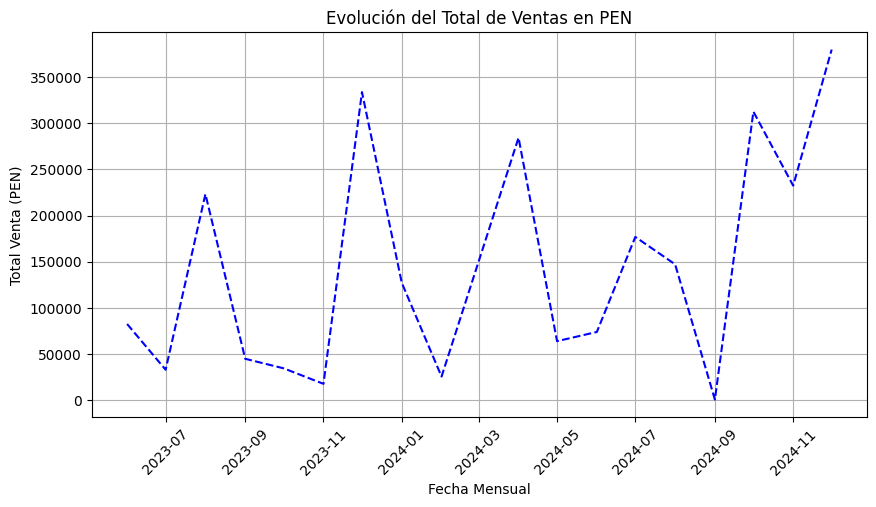

In [39]:
import matplotlib.pyplot as plt
articulo_mas_venta = df_margin_result.iloc[0]['articulo']
df_ppt = df_products.merge(df_inventory[['codigo']], how='left',left_on='articulo',right_on='codigo')
df_ppt = df_ppt[df_ppt['articulo']==articulo_mas_venta]
print(df_ppt[df_ppt['articulo']==articulo_mas_venta][['articulo','fuente_suministro']].head(1))

# Graficar la evolución con una línea conectando los puntos
plt.figure(figsize=(10,5))
plt.plot(df_ppt["fecha_mensual"], df_ppt["total_venta_pen"], linestyle="--", color="b")

# Etiquetas y título
plt.xlabel("Fecha Mensual")
plt.ylabel("Total Venta (PEN)")
plt.title("Evolución del Total de Ventas en PEN")
plt.grid(True)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.show()

In [45]:
sku = articulo_mas_venta
print(sku)

dtx-232a


In [46]:
from utils.process_data.config import DATA_PATHS
from utils.predictions.predictor import Predictor
# from utils.predictions.predictor import Predictor
predictor = Predictor()
# predictions_df = predictor.process_predictions()

data_path = DATA_PATHS['process'] / 'catusita_consolidated.csv'
cov_path = DATA_PATHS['process'] / 'df_covariables.csv'

all_monthly_data = predictor.create_monthly_sales_data(
    predictor.load_and_preprocess_data(data_path)
)
df_cov = predictor.load_covariates_data(cov_path)
df_correlaciones_sig = pd.read_csv(DATA_PATHS['process'] / 'df_correlaciones_sig.csv')

# results_df = predictor.make_final_predictions(
#     all_monthly_data, 
#     df_cov, 
#     df_correlaciones_sig
# )

##### ---------------------- prediction code
results = []
try:
    sku_data = all_monthly_data[all_monthly_data['articulo'] == sku].copy()
    last_date = sku_data['fecha'].max()
    last_date = (last_date + pd.offsets.MonthBegin(1)).normalize()
    lt = int(sku_data['lt'].iloc[-1])
    last_year = sku_data['year'].max()

    # if len(sku_data) < 7:
    #     continue

    data, feature_columns = predictor.prepare_features_for_ml(
        all_monthly_data, df_cov, df_correlaciones_sig, sku
    )

    best_config, best_model, score = predictor.evaluate_models(
        data,
        feature_columns,
        lookback_periods=[6, 12, None],
        val_year=last_year - 1
    )

    # if best_config is None:
    #     continue

    if best_config is None or best_model is None:
        results.append({
            'sku': sku,
            'lt': lt,
            'date': last_date,
            'model': np.nan,
            'real': 0,
            'catusita': np.nan,
            'lookback_period': np.nan,
            'features_used': 'none',
            'caa': np.nan,
            'caa_lt': np.nan,
            'corr_sd': np.nan,
            'loss': np.nan
        })
        print(f"SKU {sku} no pudo ser evaluado. Datos insuficientes o problema en los datos.")
        
    best_model_name, lookback = best_config

    # # Calculate test score
    # test_data = data[data['year'] == last_year]
    # if feature_columns:
    #     test_X = test_data[feature_columns]
    #     if best_model_name in ['xgboost', 'linear']:
    #         test_pred = best_model.predict(test_X)
    # else:
    #     if best_model_name in ['mean', 'median']:
    #         test_pred = [best_model] * len(test_data)
    #     else:  # ES
    #         forecast_func, alpha = best_model
    #         test_pred = []
    #         current_data = data[data['year'] < last_year]['cantidad'].values
    #         for _ in range(len(test_data)):
    #             pred = forecast_func(current_data, alpha)
    #             test_pred.append(pred)
    #             current_data = np.append(current_data, pred)

    # test_score = predictor.weighted_mape(test_data['cantidad'], test_pred)

    # # Generate future predictions
    # future_predictions = predictor.predict_future_months(
    #     data,
    #     feature_columns,
    #     best_model,
    #     best_model_name,
    #     lookback,
    #     2 * lt
    # )

    # def predict_future_months(self, data, feature_columns, best_model, 
    #                         best_model_name, lookback, num_months):
    num_months = 2 * lt
    predictions = []
    current_data = data.copy()
    current_data = current_data.sort_values(by="fecha")
    # print(current_data[-6:])

    for _ in range(num_months):
        if best_model_name in ['xgboost', 'linear']:
            pred = best_model.predict(current_data[feature_columns].iloc[-1:])[0]
        elif best_model_name in ['mean', 'median']:
            last_6_months = current_data.iloc[-6:]  # Tomar solo los últimos 6 meses
            pred = last_6_months['cantidad'].mean() if best_model_name == 'mean' else last_6_months['cantidad'].median()
        else:  # ES
            forecast_func, alpha = best_model
            lookback_data = (current_data.iloc[-lookback:] if lookback 
                            else current_data)
            pred = forecast_func(lookback_data['cantidad'].dropna(), alpha)
        
        pred = np.maximum(pred, 0)
        predictions.append(pred)
        
        new_row = current_data.iloc[-1:].copy()
        new_row['cantidad'] = pred
        new_row['fecha'] += pd.DateOffset(months=1)
        new_row['month'] = new_row['fecha'].dt.month
        new_row['year'] = new_row['fecha'].dt.year
        
        current_data = pd.concat([current_data, new_row])
        
        if feature_columns:
            for lag in range(1, 4):
                current_data[f'cantidad_lag_{lag}'] = current_data['cantidad'].shift(lag)
except Exception as e:
    print(f"Error processing SKU {sku}: {str(e)}")


c:\Users\YOGA\Desktop\repositories\caa\catusita\catusita_predictions\utils\predictions\predictor.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{col_name}_lag_{lag}'] = data[col_name].shift(lag)
c:\Users\YOGA\Desktop\repositories\caa\catusita\catusita_predictions\utils\predictions\predictor.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{col_name}_lag_{lag}'] = data[col_name].shift(lag)
c:\Users\YOGA\Desktop\repositories\caa\catusita\catusita_predictions\utils\predictions\predictor.py:69: PerformanceWar

In [47]:
predictions

[np.float64(323.5),
 np.float64(339.25),
 np.float64(347.125),
 np.float64(351.0625),
 np.float64(349.09375),
 np.float64(348.109375),
 np.float64(347.6171875),
 np.float64(347.86328125),
 np.float64(347.986328125),
 np.float64(348.0478515625),
 np.float64(348.01708984375),
 np.float64(348.001708984375)]

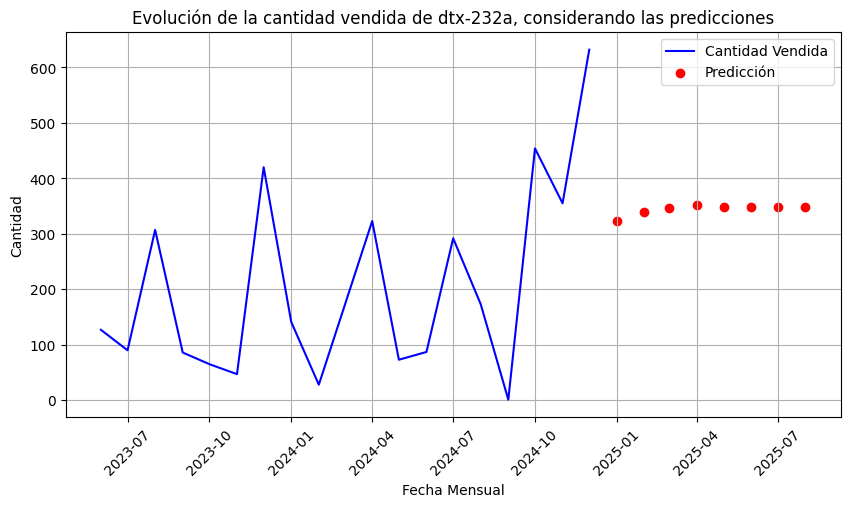

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar el DataFrame con el artículo más vendido
df_ppt2 = df_products[df_products['articulo'] == articulo_mas_venta][['fecha_mensual', 'articulo', 'cantidad']]

# Convertir la fila de df_ppt3 en columnas separadas
df_ppt3_original = df_merged[df_merged['articulo'] == articulo_mas_venta][['caa', 'caa_lt']]

# Transformar en formato adecuado (2 filas en lugar de 1)
df_ppt3 = pd.DataFrame({
    "fecha_mensual": pd.to_datetime(["2025-01-01", "2025-02-01","2025-03-01","2025-04-01","2025-05-01","2025-06-01",
                                     "2025-07-01","2025-08-01"]),#,"2025-09-01", "2025-10-01","2025-11-01","2025-12-01"]),
    "cantidad": [
                    predictions[0],
                    predictions[1],
                    predictions[2],
                    predictions[3],
                    predictions[4],
                    predictions[5],
                    predictions[6],
                    predictions[7]
                    # predictions[8],
                    # predictions[9],
                    # predictions[10],
                    # predictions[11]
                ]
})

# Graficar la evolución con una línea conectando los puntos
plt.figure(figsize=(10,5))
plt.plot(df_ppt2["fecha_mensual"], df_ppt2["cantidad"], linestyle="-", color="b", label="Cantidad Vendida")

# Agregar los puntos de predicción con las fechas correctas
plt.scatter(df_ppt3["fecha_mensual"], df_ppt3["cantidad"], color="r", marker="o", label="Predicción")

# Etiquetas y título
plt.xlabel("Fecha Mensual")
plt.ylabel("Cantidad")
plt.title(f"Evolución de la cantidad vendida de {sku}, considerando las predicciones")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.show()


In [72]:
import matplotlib.pyplot as plt
import pandas as pd

articulo_mas_venta = 'aat-017'
# Filtrar el DataFrame con el artículo más vendido
df_ppt2 = df_products[df_products['articulo'] == articulo_mas_venta][['fecha_mensual', 'articulo', 'cantidad']]

# Convertir la fila de df_ppt3 en columnas separadas
df_ppt3_original = df_merged[df_merged['articulo'] == articulo_mas_venta][['caa','compras_recomendadas']]

# Transformar en formato adecuado (2 filas en lugar de 1)
df_ppt3 = pd.DataFrame({
    "articulo": sku,
    "fecha_mensual": pd.to_datetime(["2025-01-01"]),
    "cantidad predicha": df_ppt3_original['caa'],
    "compras recomendadas": df_ppt3_original['compras_recomendadas']
}).fillna(0)

df_ppt3

C:\Users\YOGA\AppData\Local\Temp\ipykernel_7088\104302072.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).fillna(0)


,articulo,fecha_mensual,cantidad predicha,compras recomendadas
9352,dtx-232a,2025-01-01,402.0,300


In [74]:
df_merged[df_merged['articulo'] == articulo_mas_venta][['stock','backorder','caa_lt']]

,stock,backorder,caa_lt
9352,549.0,NaN,420.063099
